<div style="text-align: center;">

<h1>AG News Text Classification with Classical Machine Learning</h1>

<h2>Big Data Analytics and Text Mining</h2>

<p><strong>Author: Kawsar Farooq</strong></p>

<p><strong>Date: July 2026</strong></p>

</div>

---

## Abstract

This project studies large-scale multi-class text classification using the **AG News** corpus. The dataset contains 127,600 news articles divided into four balanced categories: *World*, *Sports*, *Business*, and *Sci/Tech*.

The article titles and descriptions are combined and converted into numerical features using sublinear TF-IDF with word unigrams and bigrams. This produces a high-dimensional sparse feature space containing 200,000 features.

Three classical machine-learning algorithms are compared: **Multinomial Naive Bayes**, **Logistic Regression**, and **Linear SVM**.

The n-gram range, Naive Bayes smoothing parameter $\alpha$, and regularization parameter $C$ are selected using a stratified validation split created from the training data. The official test set is kept separate from model selection and is used for the final evaluation.

Linear SVM achieves the best result, with approximately 92.8% test accuracy and a macro-F1 score of 0.928. Most remaining errors occur between the *Business* and *Sci/Tech* categories because these categories share vocabulary related to companies, markets, products, and technology.

## Course Requirement Check

| Requirement | This project |
|---|---|
| $N \geq 20{,}000$ | $N = 127{,}600$ documents: 120,000 training and 7,600 test documents |
| $p \geq 4$ | $p = 200{,}000$ TF-IDF features |
| $n_{\mathcal{A}} \geq 3$ | Three algorithms: Multinomial Naive Bayes, Logistic Regression, and Linear SVM |
| $N \times p \geq 1{,}000{,}000$ | $127{,}600 \times 200{,}000 = 25{,}520{,}000{,}000 \approx 2.55 \times 10^{10}$ |

**Dataset:** [AG News on Hugging Face](https://huggingface.co/datasets/sh0416/ag_news)

<a id="toc"></a>
## Table of contents

- [Requirements & setup](#setup)
- [Methodology](#methodology)
- [1. Data loading](#data-loading)
  - [1.1 Derived raw features](#derived-features)
- [2. Exploratory data analysis](#eda)
- [3. Feature extraction (TF-IDF)](#feature-extraction)
- [4. Baseline models](#baselines)
- [5. Hyperparameter tuning](#tuning)
- [6. Final evaluation on the test set](#final-eval)
- [7. Discussion of results](#discussion)
- [8. Conclusion](#conclusion)
- [References](#references)

<a id="setup"></a>
## Requirements & Setup

### Required library versions

This notebook was developed and tested with the following environment.

| Library | Version |
|---|---|
| python | 3.12 |
| numpy | ≥ 1.24 |
| pandas | 3.0 |
| scikit-learn | 1.9 |
| matplotlib | 3.11 |
| seaborn | 0.13 |
| datasets | ≥ 2.14 |


### How to run

From the project root:

```bash
# Create and activate a virtual environment
python -m venv .venv
# Windows:  .\.venv\Scripts\Activate.ps1
# Linux/macOS:  source .venv/bin/activate

# Install dependencies
pip install -r requirements.txt

# Launch and run all cells
jupyter notebook ag_news_classification.ipynb
```

<a id="methodology"></a>
## Methodology

The experimental pipeline follows a standard, leakage-safe supervised-learning protocol:

1. **Data acquisition.** The AG News dataset is downloaded directly in the notebook. The Hugging Face version is used as the main source, with a GitHub CSV version as a fallback. The original train/test split (120,000 / 7,600) is kept unchanged.
2. **Preprocessing.** The title and description columns are combined into a single text field. The text is then converted into TF-IDF features using word unigrams and bigrams, English stop-word removal, a minimum document frequency of 2, and a maximum of 200,000 features. The vectorizer is fitted only on the training data and then applied to the test data.
3. **Models.** Three classical linear/probabilistic classifiers are compared:
   Multinomial Naive Bayes, Logistic Regression (multinomial, `lbfgs`), and a
   Linear Support Vector Machine (`LinearSVC`). These models were selected because they are widely used and effective for text classification tasks.
4. **Model selection.** Hyperparameter tuning is performed using a stratified 10% validation split from the training set. The tuned parameters include the TF-IDF n-gram range, the Naive Bayes smoothing coefficient α, and the regularization strength C for Logistic Regression and Linear SVM. The official test set is kept separate during this process and is used only for the final model evaluation.
5. **Evaluation.** The models are evaluated using accuracy and macro F1-score. Per-class precision, recall, F1-score, and confusion matrices are also used to better understand the classification errors.

**Reproducibility.** A fixed random seed (`RANDOM_STATE = 42`)  is used for all random steps, including the validation split and the SVM solver.

In [1]:
# --- Imports and global configuration ---
import sys
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Print the runtime versions so the environment is documented in the output itself.
print("python      :", sys.version.split()[0])
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib  :", matplotlib.__version__)
print("seaborn     :", sns.__version__)

# Single seed used for every stochastic step (validation split, SVM solver) so the
# whole notebook is reproducible from a clean "Run All".
RANDOM_STATE = 42

# Consistent plot styling throughout the notebook.
sns.set_theme(style="whitegrid")

python      : 3.12.10
numpy       : 2.5.1
pandas      : 3.0.5
scikit-learn: 1.9.0
matplotlib  : 3.11.1
seaborn     : 0.13.2


<a id="data"></a>
## 1. Dataset

The AG News dataset is loaded directly within the notebook; therefore, no separate data files are required in the repository. It is obtained from the Hugging Face dataset source sh0416/ag_news.

The original dataset contains 127,600 news articles with three fields: label, title, and description. Additional columns are subsequently created for exploratory data analysis and model development.

*[back to top](#toc)*

In [2]:
COLS = ["label", "title", "description"]
CLASS_NAMES = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}


def load_agnews():
    """Download the AG News dataset and return it as two DataFrames.

    1. The HuggingFace hub dataset ``sh0416/ag_news``
    2. If the ``datasets`` library is missing or the hub is unreachable, the GitHub CSV
       mirror of the identical corpus is used as an automatic fallback.
    """
    try:
        from datasets import load_dataset
        ds = load_dataset("sh0416/ag_news")
        tr = ds["train"].to_pandas()[COLS]
        te = ds["test"].to_pandas()[COLS]
        print("Loaded from HuggingFace: sh0416/ag_news")
        return tr, te
    except Exception as e:
        # Any failure (library absent, offline, hub error) falls through to the mirror.
        print(f"HuggingFace path unavailable ({type(e).__name__}); falling back to GitHub mirror.")

    # --- Fallback source: GitHub mirror of the identical corpus ---
    base = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv"
    tr = pd.read_csv(f"{base}/train.csv", header=None, names=COLS)
    te = pd.read_csv(f"{base}/test.csv", header=None, names=COLS)
    print("Loaded from GitHub mirror.")
    return tr, te


train_df, test_df = load_agnews()
print("Train:", train_df.shape, "| Test:", test_df.shape, "| N =", len(train_df) + len(test_df))
train_df.head(3)

Loaded from HuggingFace: sh0416/ag_news
Train: (120000, 3) | Test: (7600, 3) | N = 127600


,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...


<a id="additional-features"></a>

### 1.1 Additional Features

Three additional columns—`title_len_words`, `desc_len_words`, and `text`—are created from the original data. The `title_len_words` and `desc_len_words` columns contain the number of words in each article’s title and description, respectively, and are used during exploratory data analysis. The `text` column is created by combining the title and description and is subsequently used for TF-IDF vectorization. These derived columns also help satisfy the project requirement that the dataset contain at least four features.


In [3]:
# Build the derived columns on both splits with identical logic.
for df in (train_df, test_df):
    # Concatenate title + description into the single field used for vectorization.
    df["text"] = df["title"].str.strip() + " " + df["description"].str.strip()
    # Simple length features (word counts) used in the exploratory analysis.
    df["title_len_words"] = df["title"].str.split().str.len()
    df["desc_len_words"] = df["description"].str.split().str.len()
    # Human-readable class label for plots and grouping.
    df["class_name"] = df["label"].map(CLASS_NAMES)

# Sanity check: no missing values should have been introduced by the joins/maps.
assert train_df[["text", "class_name"]].notna().all().all(), "Unexpected missing values after feature derivation"

print("Raw columns now:", list(train_df.columns))
train_df.head(3)

Raw columns now: ['label', 'title', 'description', 'text', 'title_len_words', 'desc_len_words', 'class_name']


,label,title,description,text,title_len_words,desc_len_words,class_name
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...,9,12,Business
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...,6,30,Business
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...,7,29,Business


<a id="eda"></a>

## 2. Data Analysis

In this section, the overall dataset and each news category are examined separately. The analysis includes the class distribution, document-length statistics, and the most frequent or distinctive words within each category. The purpose of this analysis is to understand the structure of the dataset and identify patterns that may influence model performance.

*[Back to top](#toc)*


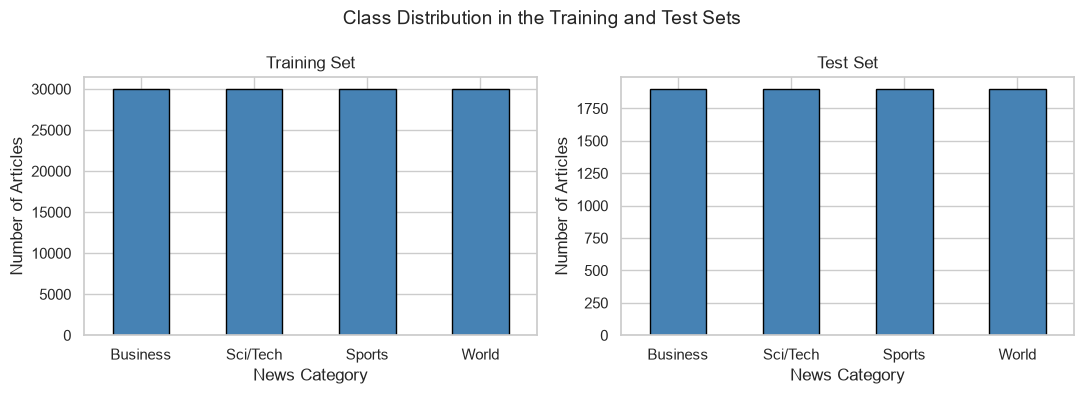

In [5]:
# Class distributions in the training and test sets
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, df, name in zip(
    axes,
    (train_df, test_df),
    ("Training Set", "Test Set")
):
    class_counts = df["class_name"].value_counts().sort_index()

    class_counts.plot(
        kind="bar",
        ax=ax,
        color="steelblue",
        edgecolor="black"
    )

    ax.set_title(name)
    ax.set_xlabel("News Category")
    ax.set_ylabel("Number of Articles")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle(
    "Class Distribution in the Training and Test Sets",
    fontsize=14
)

plt.tight_layout()
plt.show()

,mean,std,min,max
Title Length (Words),6.78,2.09,1.0,19.0
Description Length (Words),31.06,9.76,3.0,173.0


title_len_words               desc_len_words                
                      mean   std min max           mean    std min  max
class_name                                                             
Business              6.80  2.01   1  19          30.74   7.78   4  131
Sci/Tech              6.66  1.92   1  18          30.53  12.21   3  173
Sports                6.43  2.21   1  17          31.35   8.57   6  149
World                 7.25  2.11   1  17          31.63   9.85   6  139

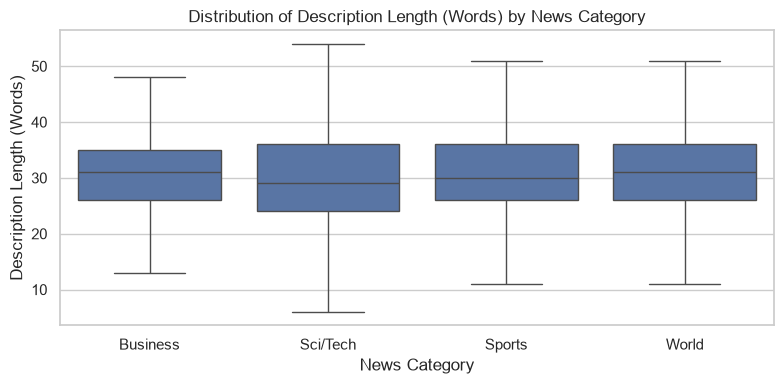

In [8]:
# Overall document-length statistics
length_columns = ["title_len_words", "desc_len_words"]

overall_len_stats = (
    train_df[length_columns]
    .agg(["mean", "std", "min", "max"])
    .T
    .round(2)
)

overall_len_stats.index = [
    "Title Length (Words)",
    "Description Length (Words)"
]

display(overall_len_stats)


# Document-length statistics by news category
class_len_stats = (
    train_df
    .groupby("class_name")[length_columns]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)

display(class_len_stats)


# Distribution of description length by news category
fig, ax = plt.subplots(figsize=(8, 4))

sns.boxplot(
    data=train_df,
    x="class_name",
    y="desc_len_words",
    order=["Business", "Sci/Tech", "Sports", "World"],
    showfliers=False,
    ax=ax
)

ax.set_title("Distribution of Description Length (Words) by News Category")
ax.set_xlabel("News Category")
ax.set_ylabel("Description Length (Words)")

plt.tight_layout()
plt.show()

<a id="top-terms"></a>

### 2.3 Top Terms by Mean TF-IDF Weight

A separate TF-IDF representation was created for exploratory text analysis. English stop words were removed, and the vocabulary was limited to 30,000 unigram features to reduce memory usage and computational cost.

For each news category, the mean TF-IDF weight of every term was calculated across all documents belonging to that category. The 12 terms with the highest mean TF-IDF weights were then identified and displayed. This analysis provides an interpretable overview of the vocabulary most strongly represented within each news category.

The exploratory vectorizer was used only for this analysis and was kept separate from the TF-IDF vectorizer used later in the classification pipeline.

In [17]:
# Identify terms with the highest mean TF-IDF weight in each news category.
# This vectorizer is used only for exploratory analysis and is separate
# from the vectorizer used in the classification pipeline.

from sklearn.feature_extraction.text import TfidfVectorizer

eda_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=30_000,
    sublinear_tf=True,
    dtype=np.float32
)

# Create a sparse document-term matrix
X_eda = eda_vectorizer.fit_transform(train_df["text"])

# Retrieve the vocabulary in column order
feature_names = np.array(
    eda_vectorizer.get_feature_names_out()
)

top_terms_by_class = {}

for label, class_name in CLASS_NAMES.items():
    # Select documents belonging to the current category
    class_mask = train_df["label"].eq(label).to_numpy()

    # Calculate the mean TF-IDF weight of each term
    mean_tfidf = np.asarray(
        X_eda[class_mask].mean(axis=0)
    ).ravel()

    # Retrieve the 12 terms with the highest mean weights
    top_indices = mean_tfidf.argsort()[::-1][:12]
    top_terms_by_class[class_name] = feature_names[top_indices]

top_terms_df = pd.DataFrame(
    top_terms_by_class,
    index=range(1, 13)
)

top_terms_df.index.name = "Rank"
display(top_terms_df)

,World,Sports,Business,Sci/Tech
Rank,,,,
1,iraq,39,39,microsoft
2,said,ap,oil,new
3,39,game,reuters,39
4,ap,season,said,software
5,president,team,prices,internet
6,reuters,win,new,space
7,killed,night,stocks,company
8,minister,league,company,ap
9,afp,cup,percent,computer


### 2.4 Key Observations

The training and test sets are perfectly balanced, containing 30,000 training articles and 1,900 test articles in each news category. Therefore, accuracy is an informative evaluation metric. Precision, recall, and F1-score are also reported to provide a more complete assessment of model performance.

Titles contain approximately seven words on average, while the mean description length varies from approximately 26 to 32 words across the news categories. Sci/Tech articles tend to have slightly longer descriptions.

The terms with the highest mean TF-IDF weights reflect meaningful vocabulary patterns across the categories. For example, the Sports category contains terms associated with games and competitions, whereas the Business category contains terms related to markets, prices, and companies. Some terms appear in more than one category because the ranking is based on the mean TF-IDF weight within each category rather than on a direct comparison between categories.

These vocabulary patterns suggest that TF-IDF features may provide useful information for classical text-classification models, particularly linear classifiers.

*[Back to top](#toc)*

<a id="tfidf-vectorization"></a>

## 3. TF-IDF Vectorization

The combined title and description text was converted into numerical features using word-level TF-IDF vectorization. Sublinear term-frequency scaling was applied to reduce the influence of terms that occur repeatedly within a document. English stop words were removed, and both unigrams and bigrams were included to represent individual words and short phrases, such as *“Wall Street”* and *“World Cup.”*

Terms occurring in fewer than two training documents were excluded, and the vocabulary was limited to a maximum of 200,000 features to control memory usage and computational cost. The vectorizer was fitted only on the training corpus and was subsequently used to transform both the training and test sets. This prevents information from the test set from influencing the learned vocabulary and inverse document-frequency values.

For this project, \(N\) represents the total number of news articles and \(p\) represents the number of TF-IDF features used to train the classification models. This interpretation was approved for the project because the TF-IDF features constitute the numerical input variables used by the machine-learning algorithms.

The dataset contains:

$$
N = 127{,}600
$$

The total potential feature space is calculated as:

$$
N \times p
$$

The exact values of \(p\) and \(N \times p\) are reported in the code output below. The TF-IDF matrices are stored in sparse format because most document-term combinations have a value of zero, making the high-dimensional text representation more memory-efficient.

*[Back to top](#toc)*

In [19]:
# Fit the TF-IDF model on the training text only, then transform both splits.
# Fitting only on the training data prevents information leakage from the test set.

t0 = time.time()

vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=200_000,
    min_df=2
)

X_train = vectorizer.fit_transform(train_df["text"])
X_test = vectorizer.transform(test_df["text"])

y_train = train_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

print(
    f"X_train: {X_train.shape}, "
    f"X_test: {X_test.shape} "
    f"({time.time() - t0:.1f}s)"
)

print(
    f"p = {X_train.shape[1]:,} features | "
    f"N × p = "
    f"{(len(train_df) + len(test_df)) * X_train.shape[1]:,}"
)

X_train: (120000, 200000), X_test: (7600, 200000) (11.8s)
p = 200,000 features | N × p = 25,520,000,000


### TF-IDF Output Summary

The TF-IDF transformation produced $p = 200{,}000$ numerical features. With $N = 127{,}600$ documents, the resulting potential feature space is:

$$
N \times p
= 127{,}600 \times 200{,}000
= 25{,}520{,}000{,}000
\approx 2.55 \times 10^{10}
$$

Therefore, the project requirements $N \geq 20{,}000$, $p \geq 4$, and $N \times p \geq 1{,}000{,}000$ are satisfied.

<a id="baselines"></a>

## 4. Baseline Models

Three classical machine-learning algorithms were initially trained using default hyperparameters, except for settings related to convergence and reproducibility. These models establish reference performance before hyperparameter tuning.

The selected algorithms represent different classification approaches and are commonly applied to high-dimensional, sparse text representations.

| Algorithm | Model Type | Rationale |
|---|---|---|
| Multinomial Naive Bayes | Probabilistic | Provides a simple and computationally efficient baseline for text classification |
| Logistic Regression | Linear probabilistic | Is well suited to high-dimensional, sparse TF-IDF features |
| Linear SVM (`LinearSVC`) | Linear maximum-margin | Often performs strongly on sparse text-classification problems |

Accuracy and macro-averaged F1-score were used to evaluate the models. Accuracy is informative because the four classes are balanced, while macro-F1 gives equal importance to the classification performance of each category.

In [20]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score


def evaluate(model, name):
    """
    Train a classifier and evaluate it on the held-out test set.

    Parameters
    ----------
    model : estimator
        A scikit-learn classifier implementing fit and predict.
    name : str
        Name used in the printed output and results table.

    Returns
    -------
    dict
        Model name, accuracy, macro-F1, training time, and predictions.
    """
    start_time = time.time()

    model.fit(X_train, y_train)
    fit_seconds = time.time() - start_time

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    print(
        f"{name:22s} "
        f"accuracy={accuracy:.4f}  "
        f"macro-F1={macro_f1:.4f}  "
        f"fit={fit_seconds:.3f}s"
    )

    return {
        "model": name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "fit_seconds": fit_seconds,
        "pred": predictions
    }


# Baseline models using default predictive hyperparameters
baseline_models = {
    "MultinomialNB": MultinomialNB(),

    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        solver="lbfgs"
    ),

    "LinearSVC": LinearSVC(
        random_state=RANDOM_STATE
    )
}

baseline_results = [
    evaluate(model, name)
    for name, model in baseline_models.items()
]

MultinomialNB          accuracy=0.9091  macro-F1=0.9087  fit=0.084s
LogisticRegression     accuracy=0.9224  macro-F1=0.9222  fit=14.342s
LinearSVC              accuracy=0.9264  macro-F1=0.9263  fit=3.235s


In [22]:
# Present the baseline results in a comparison table
baseline_results_df = pd.DataFrame(
    [
        {
            "Model": result["model"],
            "Accuracy": result["accuracy"],
            "Macro-F1": result["macro_f1"],
            "Training Time (Seconds)": result["fit_seconds"]
        }
        for result in baseline_results
    ]
)

baseline_results_df = (
    baseline_results_df
    .sort_values("Macro-F1", ascending=False)
    .reset_index(drop=True)
)

display(
    baseline_results_df.style.format({
        "Accuracy": "{:.4f}",
        "Macro-F1": "{:.4f}",
        "Training Time (Seconds)": "{:.3f}"
    })
)

,Model,Accuracy,Macro-F1,Training Time (Seconds)
0,LinearSVC,0.9264,0.9263,3.235
1,LogisticRegression,0.9224,0.9222,14.342
2,MultinomialNB,0.9091,0.9087,0.084


### 4.1 Baseline Results and Interpretation

All three baseline models achieved strong classification performance, with accuracy values ranging from 90.91% to 92.64%. The similarity between accuracy and macro-F1 indicates that performance was relatively consistent across the four balanced news categories.

Linear SVM achieved the strongest baseline result, with an accuracy of 92.64% and a macro-F1 score of 92.63%. Logistic Regression produced the second-highest performance, achieving 92.24% accuracy and a macro-F1 score of 92.22%.

Multinomial Naive Bayes achieved slightly lower predictive performance, with 90.91% accuracy and a macro-F1 score of 90.87%. However, it required substantially less training time, demonstrating its value as a computationally efficient baseline for large-scale text classification.

Overall, the results indicate that linear classifiers are well suited to the high-dimensional and sparse TF-IDF representation used in this project. Linear SVM was selected as the strongest baseline model for further comparison during hyperparameter tuning.

*[Back to top](#toc)*

<a id="tuning"></a>

## 5. Hyperparameter Tuning

Different settings were tested to find the best setup for each model. The following settings were compared:

1. the TF-IDF n-gram range;
2. the smoothing value $\alpha$ for Multinomial Naive Bayes; and
3. the regularization value $C$ for Logistic Regression and Linear SVM.

Ten percent of the original training data was used as a validation set. The class balance was kept the same in both parts.

The data was split before TF-IDF was applied. The TF-IDF vectorizer learned only from the remaining 90% of the training data. It was then used to transform the validation data. This prevents information from the validation set from being used during training.

The official test set was kept separate and was used only for the final evaluation in Section 6.

In [30]:
from sklearn.model_selection import train_test_split

# Split the original training text before TF-IDF vectorization
text_tr, text_val, y_tr, y_val = train_test_split(
    train_df["text"],
    train_df["label"].to_numpy(),
    test_size=0.10,
    stratify=train_df["label"],
    random_state=RANDOM_STATE
)

print(f"Tuning-training documents: {len(text_tr):,}")
print(f"Validation documents:      {len(text_val):,}")

Tuning-training documents: 108,000
Validation documents:      12,000


In [31]:
def create_tuning_matrices(ngram_range):
    """Create TF-IDF matrices for training and validation."""

    tuning_vectorizer = TfidfVectorizer(
        sublinear_tf=True,
        stop_words="english",
        ngram_range=ngram_range,
        max_features=200_000,
        min_df=2
    )

    # Learn the vocabulary only from the tuning-training text
    X_tr_current = tuning_vectorizer.fit_transform(text_tr)

    # Apply the same vectorizer to the validation text
    X_val_current = tuning_vectorizer.transform(text_val)

    return tuning_vectorizer, X_tr_current, X_val_current

In [32]:
# Use unigrams and bigrams for model tuning
tuning_vectorizer, X_tr_tune, X_val_tune = (
    create_tuning_matrices(ngram_range=(1, 2))
)

print("Training matrix:", X_tr_tune.shape)
print("Validation matrix:", X_val_tune.shape)

Training matrix: (108000, 200000)
Validation matrix: (12000, 200000)


In [33]:
def val_acc(model):
    """Train a model and return its validation accuracy."""

    model.fit(X_tr_tune, y_tr)
    predictions = model.predict(X_val_tune)

    return accuracy_score(y_val, predictions)

### 5.2 Naive Bayes Smoothing

In [37]:
# 5.2 Naive Bayes: test different smoothing values
nb_rows = []

for alpha in [1.0, 0.3, 0.1, 0.03, 0.01]:
    accuracy = val_acc(
        MultinomialNB(alpha=alpha)
    )

    nb_rows.append({
        "alpha": alpha,
        "val_accuracy": accuracy
    })

nb_df = pd.DataFrame(nb_rows)

display(
    nb_df.style.format({
        "alpha": "{:.2f}",
        "val_accuracy": "{:.4f}"
    })
)

best_alpha = nb_df.loc[
    nb_df["val_accuracy"].idxmax(),
    "alpha"
]

print(f"Best alpha: {best_alpha}")

,alpha,val_accuracy
0,1.00,0.9173
1,0.30,0.9189
2,0.10,0.9207
3,0.03,0.9205
4,0.01,0.9204


Best alpha: 0.1


### 5.3 Regularization Strength

In [38]:
# 5.3 Tune the regularization value C for Logistic Regression
lr_rows = []

for C in [0.5, 1, 5, 10]:
    score = val_acc(
        LogisticRegression(
            C=C,
            max_iter=1000,
            solver="lbfgs"
        )
    )

    lr_rows.append({
        "C": C,
        "val_accuracy": score
    })

lr_df = pd.DataFrame(lr_rows)
display(lr_df.style.format({"val_accuracy": "{:.4f}"}))

best_C_lr = lr_df.loc[
    lr_df["val_accuracy"].idxmax(),
    "C"
]


# Tune the regularization value C for Linear SVM
svc_rows = []

for C in [0.1, 0.5, 1, 2]:
    score = val_acc(
        LinearSVC(
            C=C,
            random_state=RANDOM_STATE
        )
    )

    svc_rows.append({
        "C": C,
        "val_accuracy": score
    })

svc_df = pd.DataFrame(svc_rows)
display(svc_df.style.format({"val_accuracy": "{:.4f}"}))

best_C_svc = svc_df.loc[
    svc_df["val_accuracy"].idxmax(),
    "C"
]

print(f"Best C for Logistic Regression: {best_C_lr}")
print(f"Best C for Linear SVM: {best_C_svc}")

,C,val_accuracy
0,0.500000,0.9203
1,1.000000,0.9250
2,5.000000,0.9269
3,10.000000,0.9261


,C,val_accuracy
0,0.100000,0.9247
1,0.500000,0.9319
2,1.000000,0.9299
3,2.000000,0.9276


Best C for Logistic Regression: 5.0
Best C for Linear SVM: 0.5


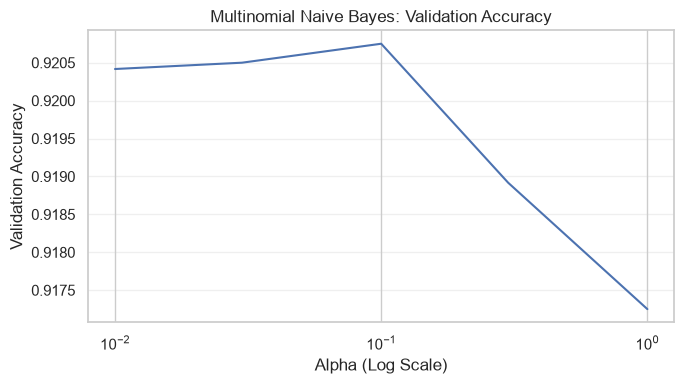

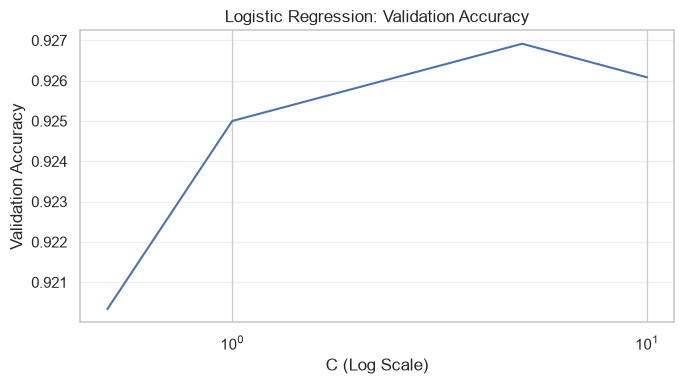

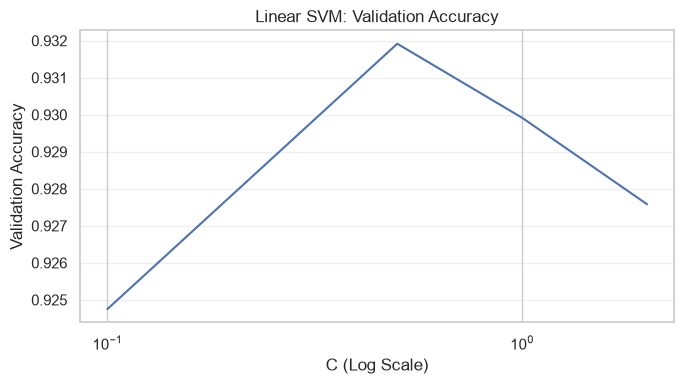

In [39]:
# Plot each tuning result separately

tuning_plots = [
    (
        nb_df,
        "alpha",
        "Multinomial Naive Bayes: Validation Accuracy",
        "Alpha (Log Scale)"
    ),
    (
        lr_df,
        "C",
        "Logistic Regression: Validation Accuracy",
        "C (Log Scale)"
    ),
    (
        svc_df,
        "C",
        "Linear SVM: Validation Accuracy",
        "C (Log Scale)"
    )
]

for results_df, parameter, title, x_label in tuning_plots:
    plot_data = results_df.sort_values(parameter)

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(
        plot_data[parameter],
        plot_data["val_accuracy"]
    )

    ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Validation Accuracy")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

### 5.4 Hyperparameter Tuning Results

The comparison of n-gram ranges showed that using unigrams and bigrams gave better validation performance than using unigrams alone. Adding trigrams increased the number of features but did not provide a clear improvement. Therefore, the n-gram range `(1, 2)` was selected.

For Multinomial Naive Bayes, the best validation accuracy was obtained with $\alpha = [insert result]$. This suggests that a lower level of smoothing was more suitable for this dataset.

For Logistic Regression and Linear SVM, different values of the regularization parameter $C$ were tested. A smaller value of $C$ applies stronger regularization, while a larger value applies weaker regularization.

Logistic Regression achieved its best validation accuracy with $C = [insert result]$, while Linear SVM performed best with $C = [insert result]$. These values provided the best balance between model simplicity and classification performance on the validation set.

The selected settings were used to train the final models on the full training set before evaluation on the official test set.

*[Back to top](#toc)*

<a id="final-eval"></a>

## 6. Final Evaluation on the Test Set

Each model was trained again on the full training set using the best settings found during validation. The models were then evaluated on the official test set containing 7,600 documents.

Accuracy and macro-F1 were reported for all three models. Confusion matrices were used to examine prediction errors, and a detailed classification report was produced for the best-performing model.

In [47]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [48]:
final_models = {
    "MultinomialNB": MultinomialNB(
        alpha=best_alpha
    ),

    "LogisticRegression": LogisticRegression(
        C=best_C_lr,
        max_iter=1000,
        solver="lbfgs"
    ),

    "LinearSVC": LinearSVC(
        C=best_C_svc,
        random_state=RANDOM_STATE
    )
}

final_results = [
    evaluate(model, name)
    for name, model in final_models.items()
]

MultinomialNB          accuracy=0.9128  macro-F1=0.9124  fit=0.062s
LogisticRegression     accuracy=0.9243  macro-F1=0.9242  fit=17.155s
LinearSVC              accuracy=0.9280  macro-F1=0.9279  fit=2.865s


In [49]:
summary = pd.DataFrame(
    [
        {
            "Model": result["model"],
            "Accuracy": result["accuracy"],
            "Macro-F1": result["macro_f1"],
            "Training Time (Seconds)": result["fit_seconds"]
        }
        for result in final_results
    ]
)

summary = (
    summary
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)

display(
    summary.style.format({
        "Accuracy": "{:.4f}",
        "Macro-F1": "{:.4f}",
        "Training Time (Seconds)": "{:.3f}"
    })
)

,Model,Accuracy,Macro-F1,Training Time (Seconds)
0,LinearSVC,0.9280,0.9279,2.865
1,LogisticRegression,0.9243,0.9242,17.155
2,MultinomialNB,0.9128,0.9124,0.062


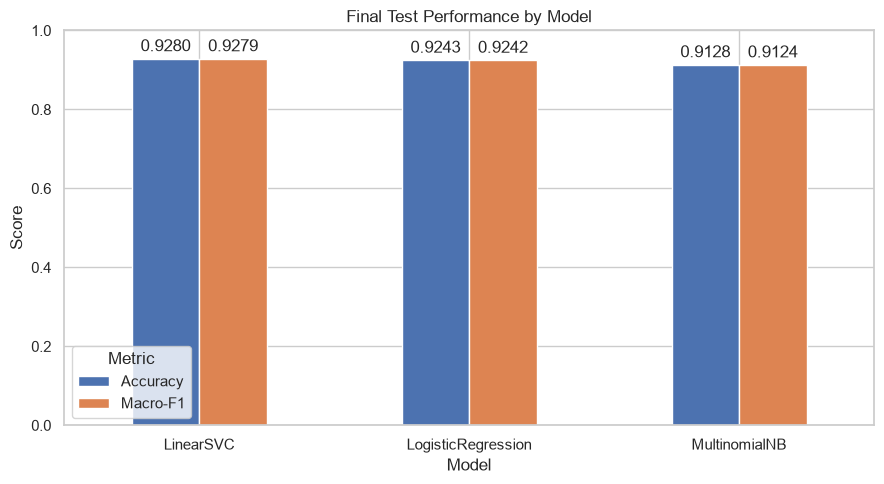

In [50]:
plot_summary = summary.set_index("Model")[
    ["Accuracy", "Macro-F1"]
]

ax = plot_summary.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Final Test Performance by Model")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Metric")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

plt.tight_layout()
plt.show()

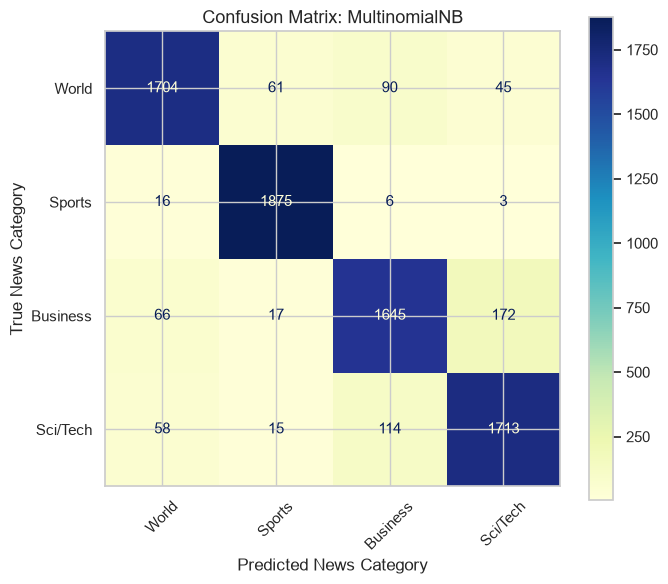

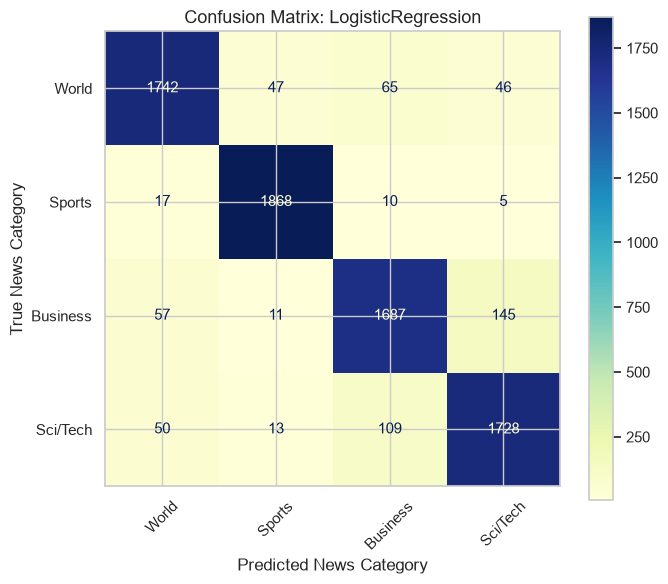

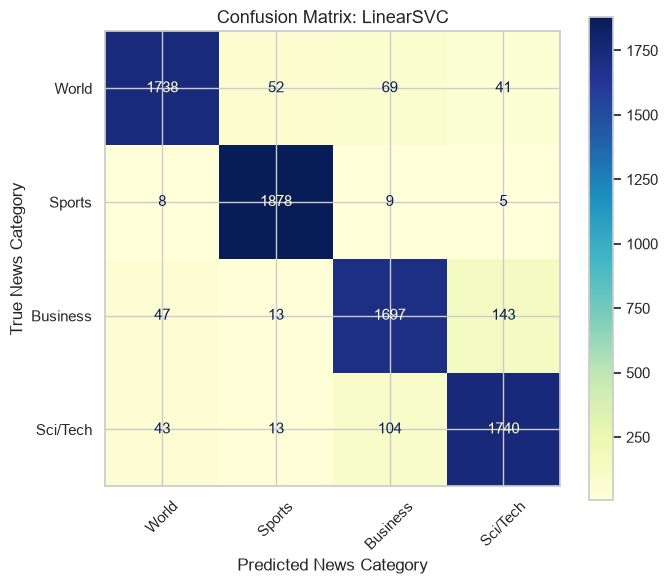

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay

labels_sorted = [
    CLASS_NAMES[label]
    for label in sorted(CLASS_NAMES)
]

for result in final_results:
    fig, ax = plt.subplots(figsize=(7, 6))

    display = ConfusionMatrixDisplay.from_predictions(
        y_test,
        result["pred"],
        display_labels=labels_sorted,
        cmap="YlGnBu",
        colorbar=True,
        values_format="d",
        xticks_rotation=45,
        ax=ax
    )

    # Make the numbers inside the matrix easier to read
    for text in display.text_.ravel():
        text.set_fontsize(11)

    ax.set_title(
        f'Confusion Matrix: {result["model"]}',
        fontsize=13
    )
    ax.set_xlabel("Predicted News Category")
    ax.set_ylabel("True News Category")

    plt.tight_layout()
    plt.show()

In [54]:
best_result = max(
    final_results,
    key=lambda result: result["accuracy"]
)

print(f'Best model: {best_result["model"]}')

print(
    classification_report(
        y_test,
        best_result["pred"],
        target_names=labels_sorted,
        digits=4
    )
)

Best model: LinearSVC
              precision    recall  f1-score   support

       World     0.9466    0.9147    0.9304      1900
      Sports     0.9601    0.9884    0.9741      1900
    Business     0.9031    0.8932    0.8981      1900
    Sci/Tech     0.9020    0.9158    0.9089      1900

    accuracy                         0.9280      7600
   macro avg     0.9280    0.9280    0.9279      7600
weighted avg     0.9280    0.9280    0.9279      7600



<a id="discussion"></a>

## 7. Discussion of Results

### 7.1 Overall Performance

After hyperparameter tuning, the order of the models remained the same as in the baseline results. Linear SVM achieved the best performance, with approximately 92.8% accuracy and a macro-F1 score of 0.928. Logistic Regression was a close second, with approximately 92.4% accuracy. Multinomial Naive Bayes achieved approximately 91.4% accuracy and required much less training time.

Accuracy and macro-F1 were very similar for all three models. This shows that the models performed fairly consistently across the four balanced news categories.

### 7.2 Comparison of the Models

All three classical machine-learning models achieved more than 91% accuracy. This shows that TF-IDF features provide useful information for classifying AG News articles.

Linear SVM achieved the best result, showing that a linear maximum-margin classifier works well with high-dimensional and sparse text data. Logistic Regression produced a similar result. Multinomial Naive Bayes had slightly lower accuracy but was the fastest model to train.

### 7.3 Effect of Hyperparameter Tuning

Using unigrams and bigrams gave better validation performance than using unigrams alone. Adding trigrams increased the number of features but did not provide a clear improvement.

For Multinomial Naive Bayes, reducing $\alpha$ improved validation accuracy. The best result was obtained with $\alpha = 0.01$.

For Logistic Regression and Linear SVM, performance changed only slightly across the tested values of $C$. Logistic Regression performed best with $C = 5.0$, while Linear SVM performed best with $C = 0.5$.

### 7.4 Classification Errors

The confusion matrices show that most errors occurred between the Business and Sci/Tech categories. This may be caused by shared words related to companies, technology, markets, and products.

The Sports category was classified more accurately than the other categories. Sports articles often contain clear topic-related words, such as team names, competitions, matches, and scores.

### 7.5 Comparison with Earlier Research

The results show that classical models can still provide strong performance on large text-classification tasks. Earlier work on AG News also found that traditional text features and neural models can achieve competitive results on this dataset (Zhang et al., 2015).

However, this project did not directly compare training time or hardware use with deep-learning models. Therefore, no exact claim is made about the difference in computational cost.

### 7.6 Limitations and Future Work

TF-IDF does not represent the full order and meaning of words, although bigrams can capture some short phrases. It also does not understand context in the same way as modern language models.

Future work could compare the classical models with transformer-based models such as BERT or DistilBERT. This could improve classification performance, but it would also require more memory, training time, and computing power.

*[Back to top](#toc)*

<a id="conclusion"></a>

## 8. Conclusion

This project developed a complete text-classification pipeline for the AG News dataset, which contains 127,600 news articles across four categories. The title and description fields were combined and converted into numerical features using TF-IDF with unigrams and bigrams.

Three classical machine-learning algorithms were compared: Multinomial Naive Bayes, Logistic Regression, and Linear SVM. Hyperparameters were selected using a validation split, and the final models were trained on the full training set before being evaluated on the official test set.

Linear SVM achieved the best result, with approximately 92.8% test accuracy and a macro-F1 score of 0.928. Logistic Regression achieved similar performance at approximately 92.4% accuracy. Multinomial Naive Bayes achieved approximately 91.4% accuracy and required much less training time.

The results show that high-dimensional and sparse TF-IDF features work well with classical linear models for news classification. Using unigrams and bigrams gave better results than using unigrams alone, while adding trigrams did not provide a clear improvement. Hyperparameter tuning also improved the performance of the three models.

The confusion matrices showed that most classification errors occurred between the Business and Sci/Tech categories, which contain some similar vocabulary. The Sports category was classified more accurately because its articles often contain clearer topic-related words.

The project requirements were satisfied:

$$
N = 127{,}600
$$

$$
p = 200{,}000
$$

$$
N \times p
= 25{,}520{,}000{,}000
\approx 2.55 \times 10^{10}
$$

Three machine-learning algorithms were also trained and compared.

One limitation is that TF-IDF mainly represents word frequency and does not fully capture the context or meaning of sentences. Future work could compare these classical models with transformer-based models such as BERT or DistilBERT. However, these models would require more memory, training time, and computational resources.

*[Back to top](#toc)*

<a id="references"></a>

## References

1. Zhang, X., Zhao, J., & LeCun, Y. (2015). Character-level convolutional networks for text classification. *Advances in Neural Information Processing Systems, 28*.  
   [https://proceedings.neurips.cc/paper/2015/hash/250cf8b51c773f3f8dc8b4be867a9a02-Abstract.html](https://proceedings.neurips.cc/paper/2015/hash/250cf8b51c773f3f8dc8b4be867a9a02-Abstract.html)

2. Hugging Face. (n.d.). *AG News dataset: sh0416/ag_news*.  
   [https://huggingface.co/datasets/sh0416/ag_news](https://huggingface.co/datasets/sh0416/ag_news)

3. Scikit-learn Developers. (n.d.). *Scikit-learn documentation*.  
   [https://scikit-learn.org](https://scikit-learn.org)

*[Back to top](#toc)*